In [21]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler, QuantileTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [7]:
dataset = pd.read_csv("../../data/processed_dataset/GLRM/glrm_radiomics_dataset_cleaned.csv")
dataset = dataset.drop(columns=['mask_path', 'ct_image_path', 'z_middle_global', 'patient_id'])
dataset.describe()

,rlm_sre_2d_avg_fbn_n16,rlm_lre_2d_avg_fbn_n16,rlm_lgre_2d_avg_fbn_n16,rlm_hgre_2d_avg_fbn_n16,rlm_srlge_2d_avg_fbn_n16,rlm_srhge_2d_avg_fbn_n16,rlm_lrlge_2d_avg_fbn_n16,rlm_lrhge_2d_avg_fbn_n16,rlm_glnu_2d_avg_fbn_n16,rlm_glnu_norm_2d_avg_fbn_n16,rlm_rlnu_2d_avg_fbn_n16,rlm_rlnu_norm_2d_avg_fbn_n16,rlm_r_perc_2d_avg_fbn_n16,rlm_gl_var_2d_avg_fbn_n16,rlm_rl_var_2d_avg_fbn_n16,rlm_rl_entr_2d_avg_fbn_n16
count,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000,50917.000000
mean,0.833410,3.264574,0.042195,98.481085,0.032257,80.878248,0.471880,342.328435,81.204809,0.130932,387.960531,0.668427,0.777588,8.969514,1.144944,4.117908
std,0.098414,7.228457,0.050039,35.441445,0.028563,25.523776,5.252084,814.464917,83.397409,0.045725,357.160361,0.143814,0.138131,5.531208,4.274106,0.328366
min,0.098794,1.000000,0.005348,3.620913,0.001918,2.681750,0.014259,14.374612,1.811067,0.065970,3.494527,0.074717,0.055027,0.000000,0.000000,2.128661
25%,0.803107,1.525604,0.018589,77.735703,0.016391,67.021392,0.028381,126.848039,24.608821,0.103653,136.949981,0.603514,0.740147,5.683266,0.186097,3.921968
50%,0.867593,1.745013,0.025948,96.136001,0.022995,82.452821,0.039112,168.748246,55.858113,0.118690,273.709289,0.710624,0.826596,7.377895,0.272699,4.042231
75%,0.897303,2.412658,0.043256,117.327009,0.036530,97.989336,0.077813,242.331988,108.148061,0.142185,521.785576,0.766343,0.865818,10.397708,0.557127,4.242353
max,1.000000,577.765636,0.888219,239.114616,0.402759,173.679035,577.613483,29613.412076,1553.303375,1.000000,4489.171542,1.000000,1.000000,53.997316,237.418412,5.944103


## Distibution des valeurs

Index(['rlm_sre_2d_avg_fbn_n16', 'rlm_lre_2d_avg_fbn_n16',
       'rlm_lgre_2d_avg_fbn_n16', 'rlm_hgre_2d_avg_fbn_n16',
       'rlm_srlge_2d_avg_fbn_n16', 'rlm_srhge_2d_avg_fbn_n16',
       'rlm_lrlge_2d_avg_fbn_n16', 'rlm_lrhge_2d_avg_fbn_n16',
       'rlm_glnu_2d_avg_fbn_n16', 'rlm_glnu_norm_2d_avg_fbn_n16',
       'rlm_rlnu_2d_avg_fbn_n16', 'rlm_rlnu_norm_2d_avg_fbn_n16',
       'rlm_r_perc_2d_avg_fbn_n16', 'rlm_gl_var_2d_avg_fbn_n16',
       'rlm_rl_var_2d_avg_fbn_n16', 'rlm_rl_entr_2d_avg_fbn_n16'],
      dtype='str')


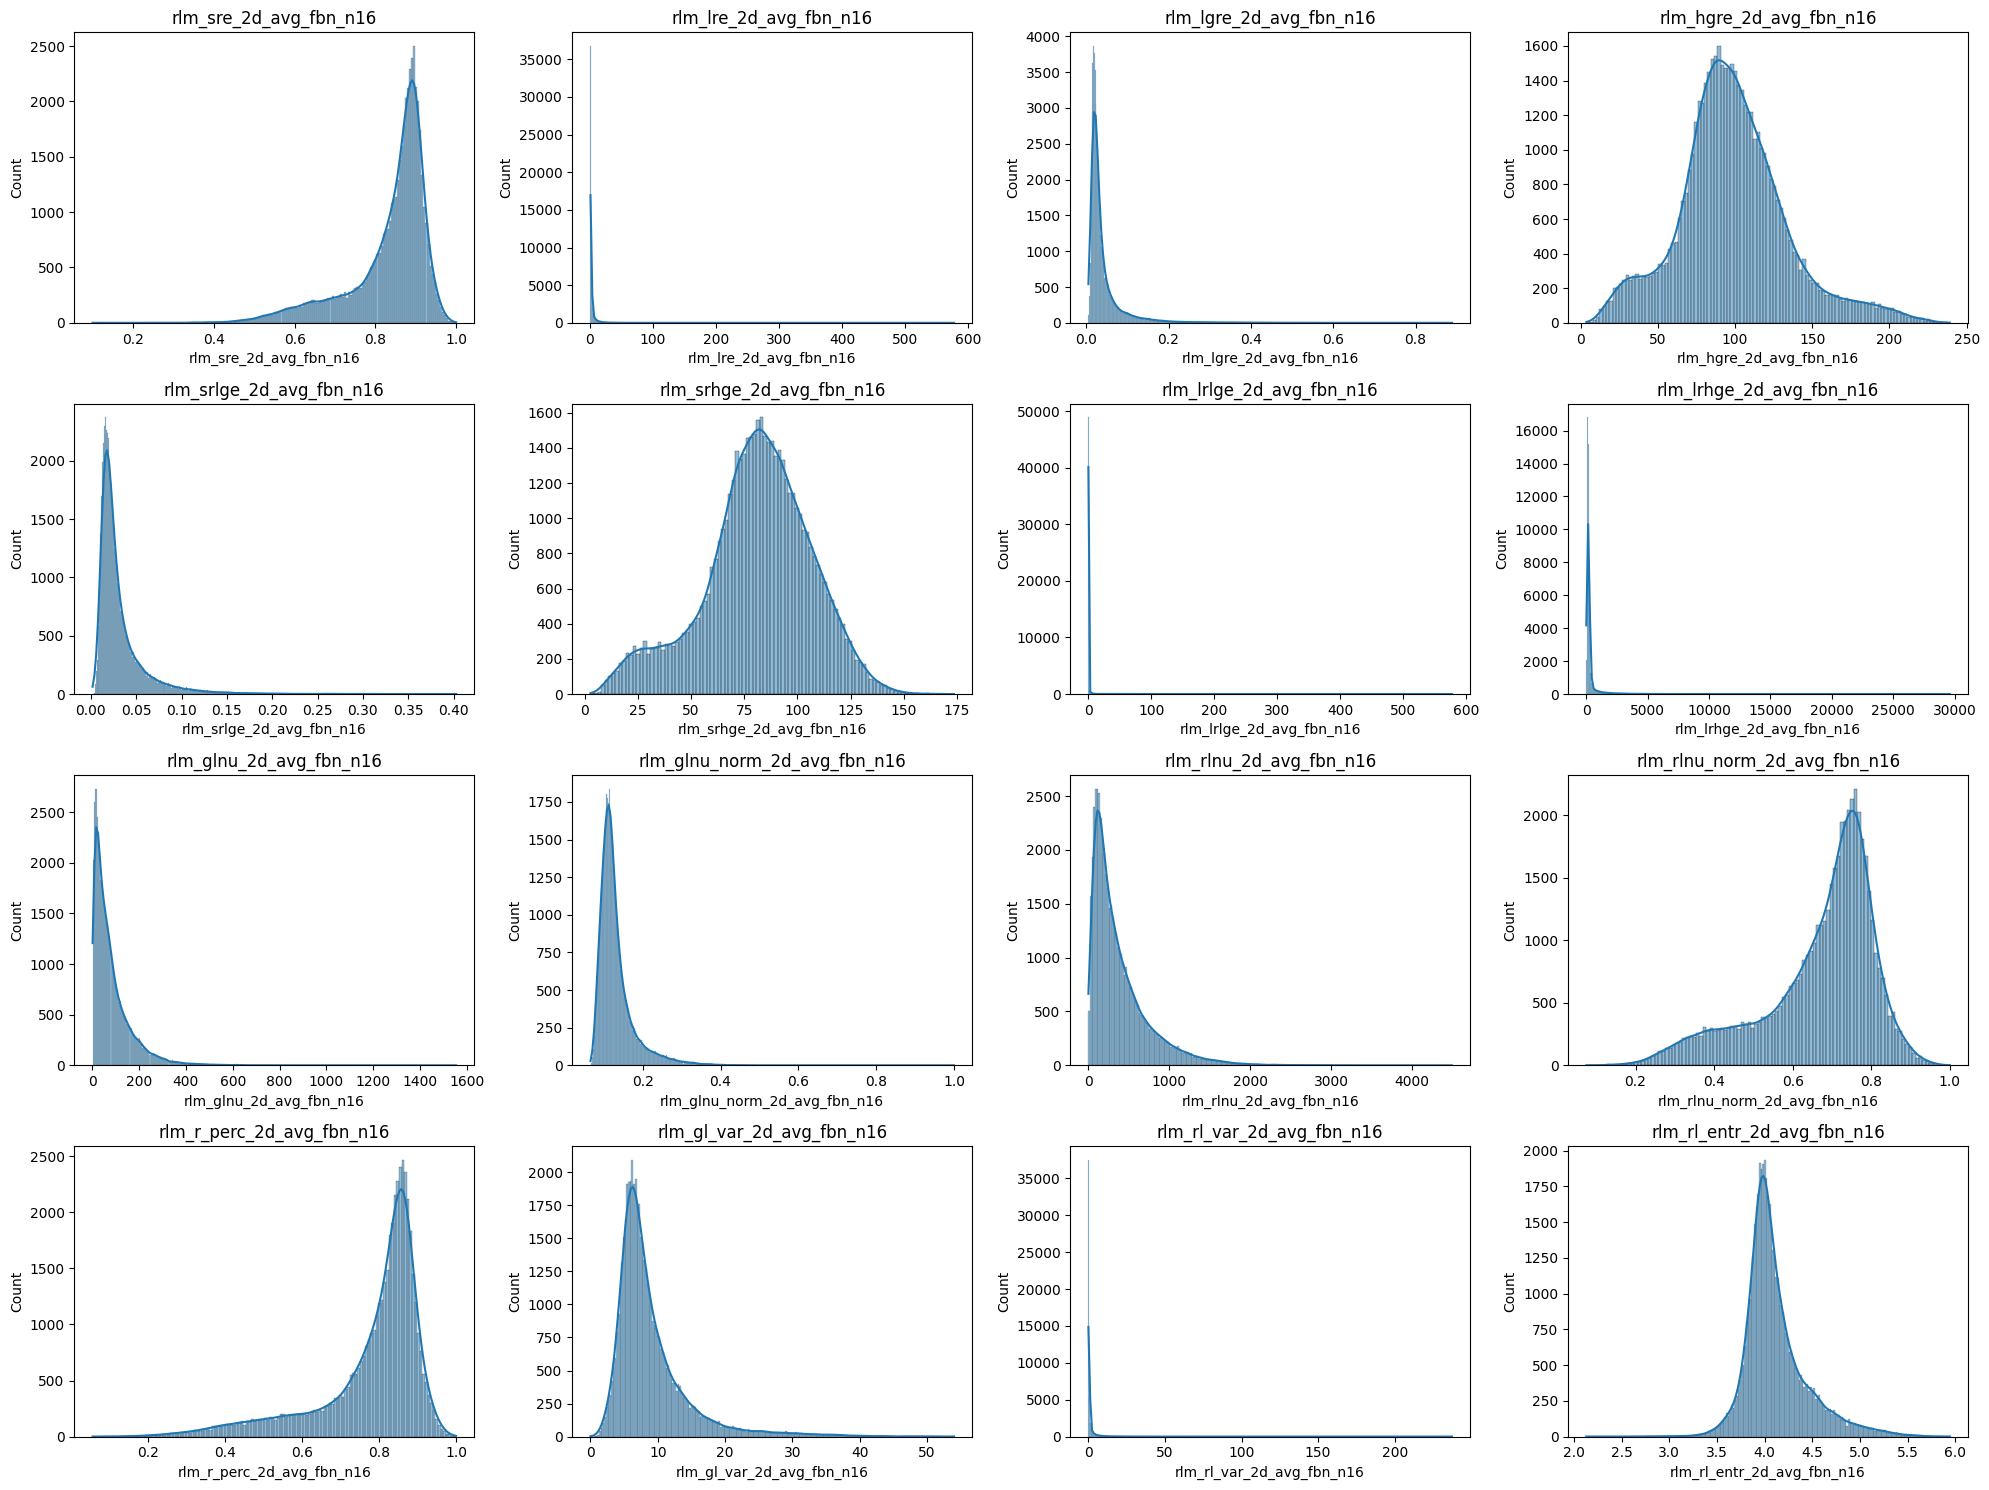

In [10]:
cols = dataset.columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols 
print(cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(dataset[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [53]:
QUANTILE_FEATURES = ['rlm_rl_entr_2d_avg_fbn_n16', 'rlm_gl_var_2d_avg_fbn_n16', 'rlm_glnu_norm_2d_avg_fbn_n16', 'rlm_rlnu_norm_2d_avg_fbn_n16', 'rlm_lre_2d_avg_fbn_n16', 'rlm_lgre_2d_avg_fbn_n16','rlm_srlge_2d_avg_fbn_n16', 'rlm_lrlge_2d_avg_fbn_n16', 'rlm_lrhge_2d_avg_fbn_n16', 'rlm_rl_var_2d_avg_fbn_n16']
POWER_FEATURES = ['rlm_hgre_2d_avg_fbn_n16', 'rlm_srhge_2d_avg_fbn_n16', 'rlm_glnu_2d_avg_fbn_n16', 'rlm_rlnu_2d_avg_fbn_n16', 'rlm_sre_2d_avg_fbn_n16', 'rlm_r_perc_2d_avg_fbn_n16']

## Trasformation application

In [27]:
def plot_features_separate(dataset_data, features, title):
    n_features = len(features)
    n_cols = max(n_features // 2, 4)
    n_rows = (n_features + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()
    
    for i, f in enumerate(features):
        sns.histplot(dataset_data[f], kde=True, color='skyblue', ax=axes[i])
        axes[i].set_title(f"{f}")
    
    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

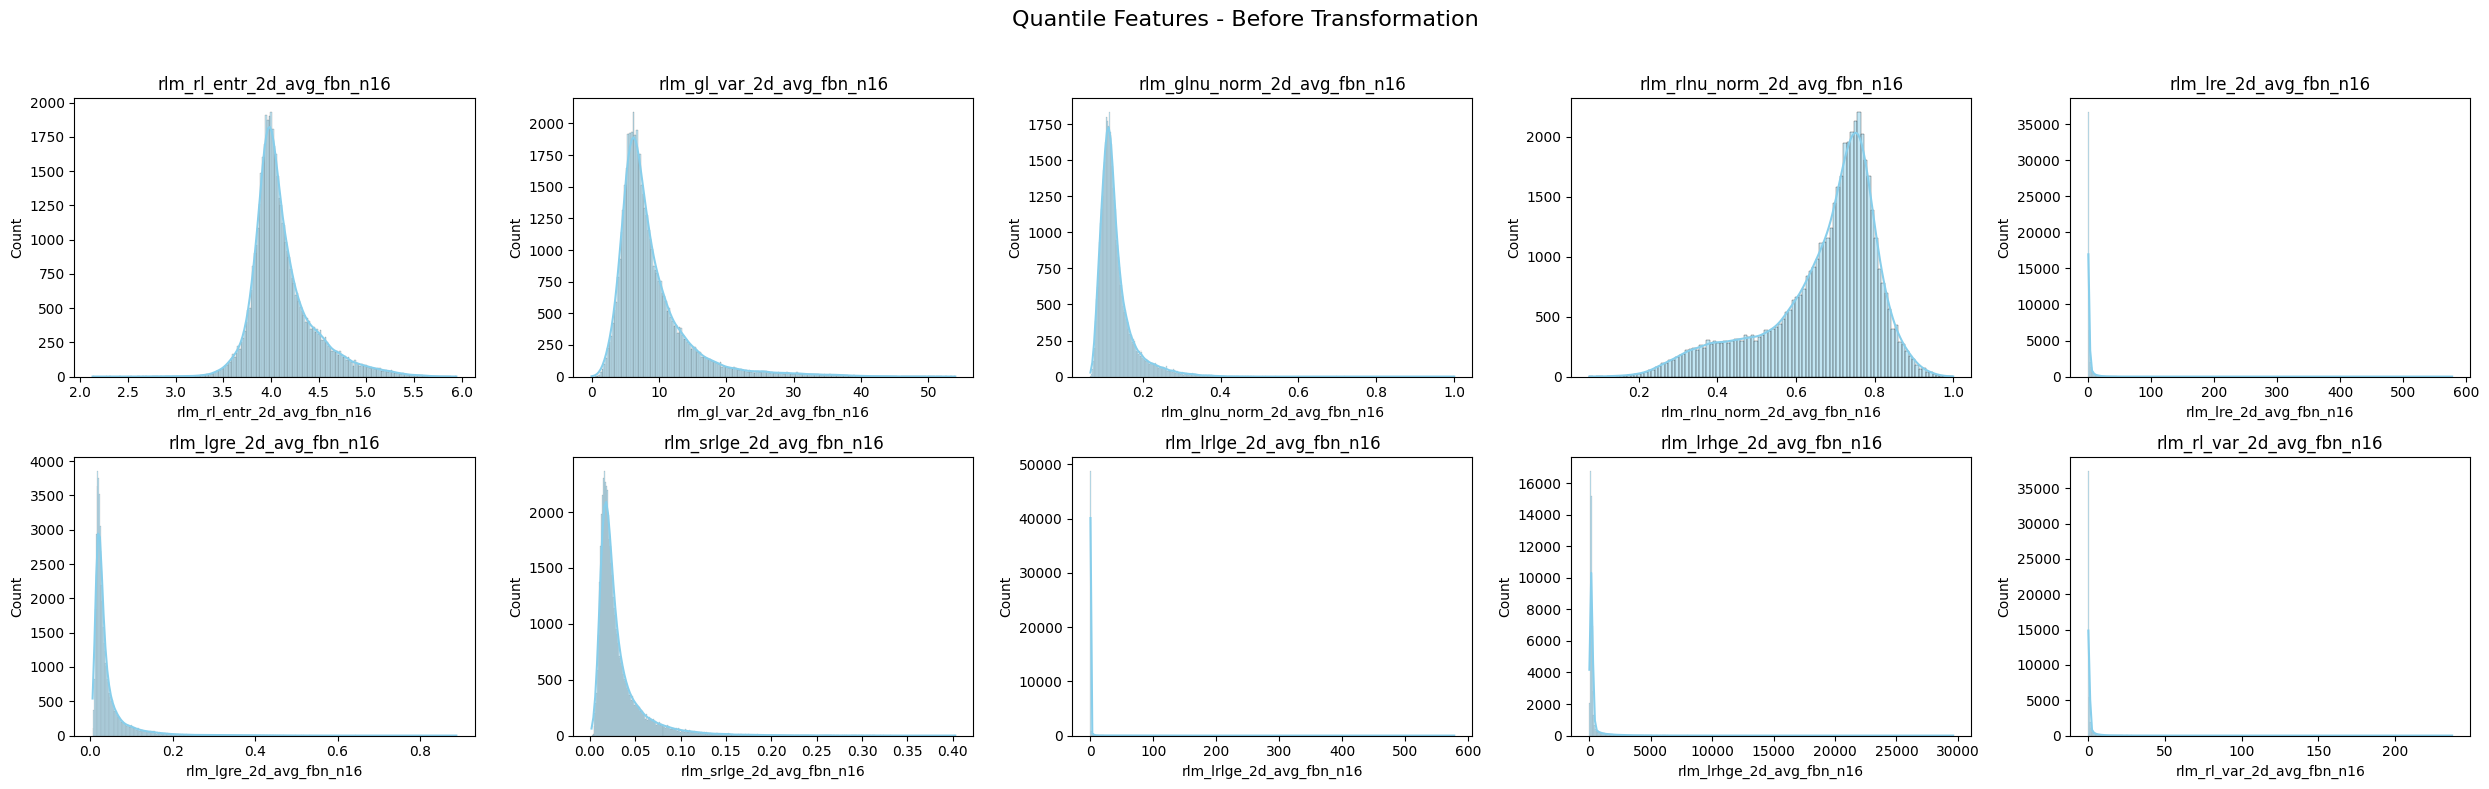

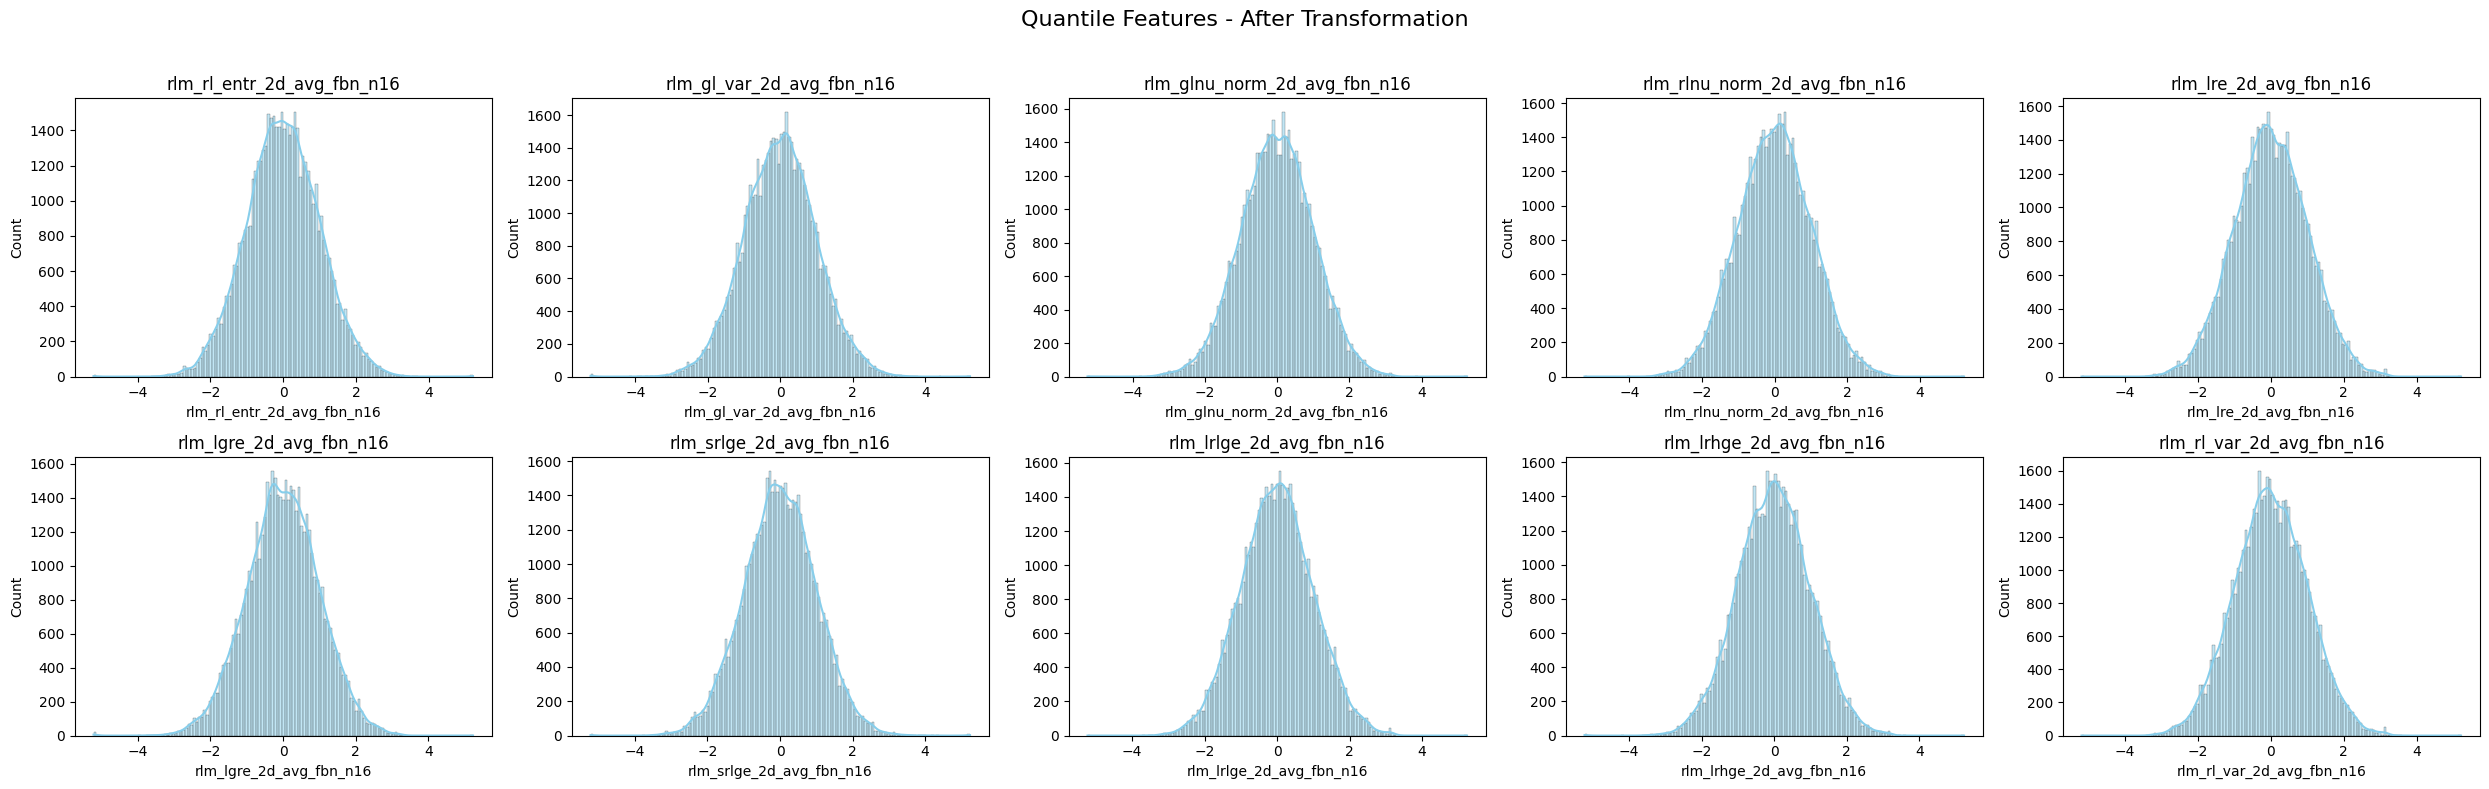

In [54]:
# Quantile Transformation with StandardScaler

quantile_df = dataset.copy()
qt = QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=1000)
scaler_quantile = StandardScaler()
quantile_df[QUANTILE_FEATURES] = scaler_quantile.fit_transform(qt.fit_transform(quantile_df[QUANTILE_FEATURES]))
plot_features_separate(dataset, QUANTILE_FEATURES, "Quantile Features - Before Transformation")
plot_features_separate(quantile_df, QUANTILE_FEATURES, "Quantile Features - After Transformation")

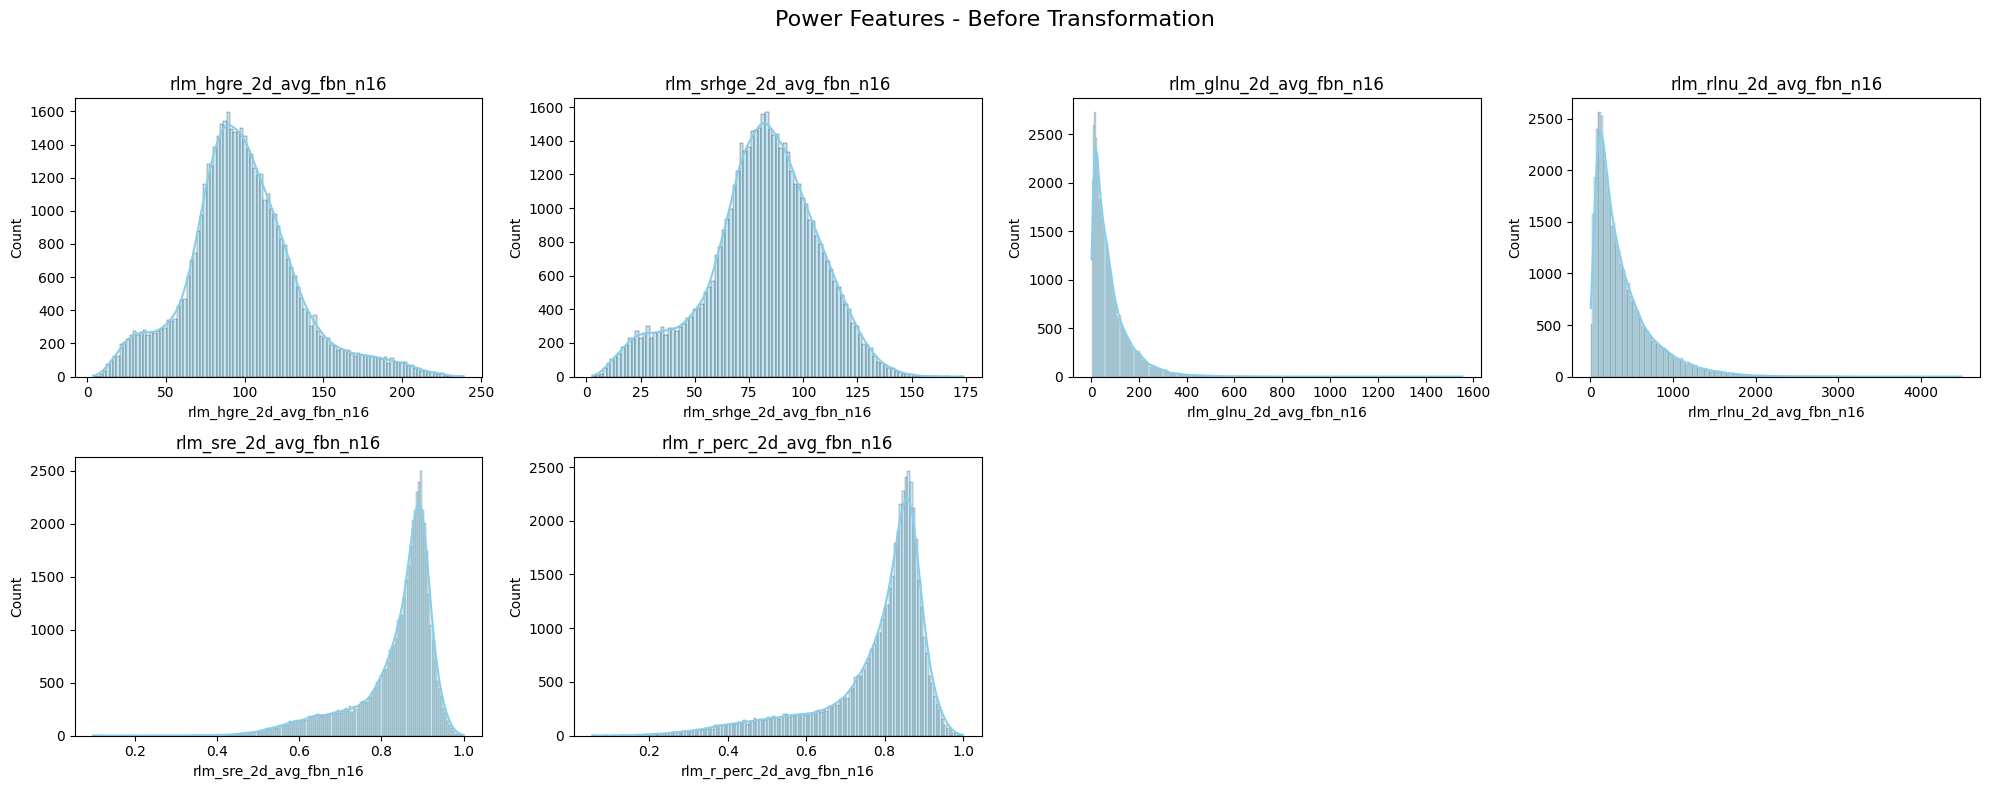

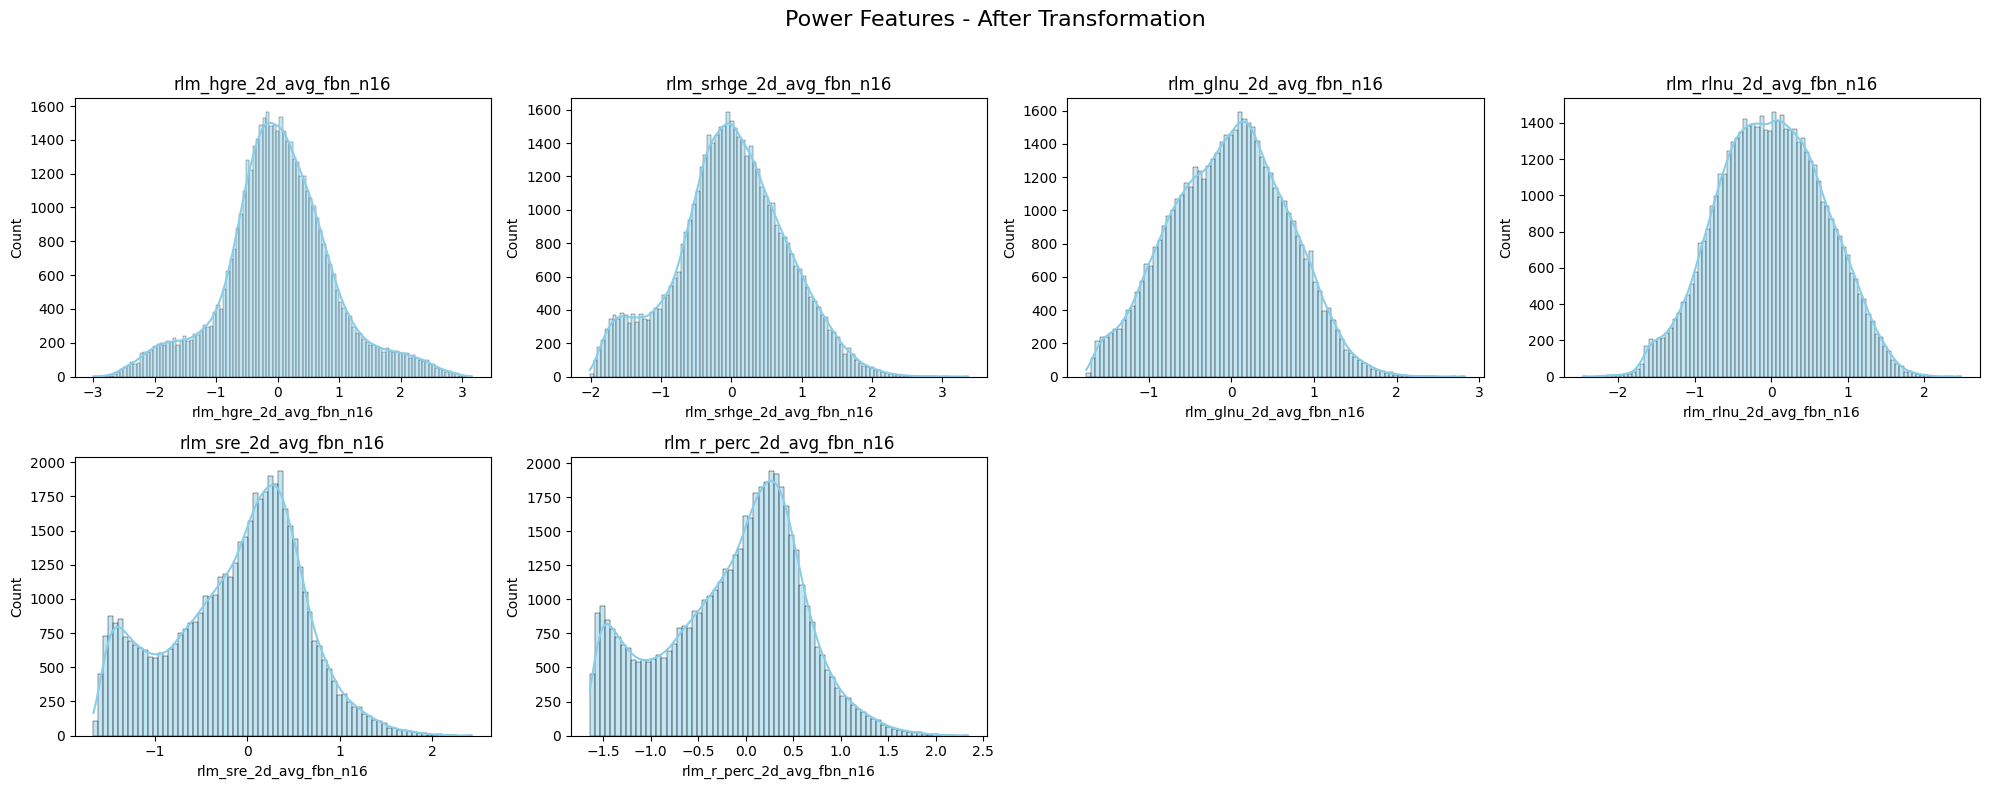

In [51]:
# Power Features
power_df = dataset.copy()
pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_power = RobustScaler()
power_df[POWER_FEATURES] = scaler_power.fit_transform(pt_yeo.fit_transform(power_df[POWER_FEATURES]))
plot_features_separate(dataset, POWER_FEATURES, "Power Features - Before Transformation")
plot_features_separate(power_df, POWER_FEATURES, "Power Features - After Transformation")

## Per-feature transformation

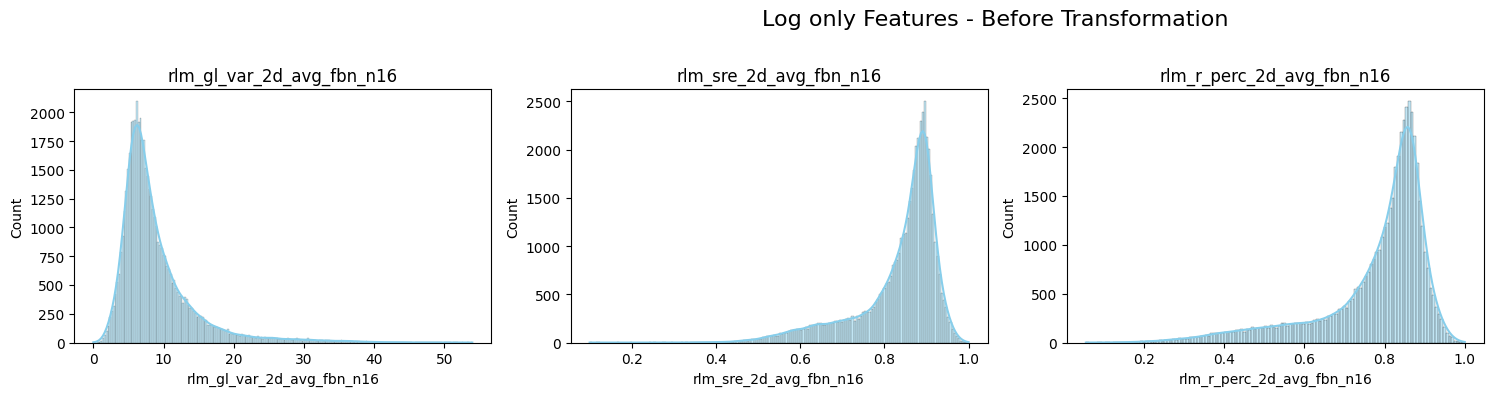

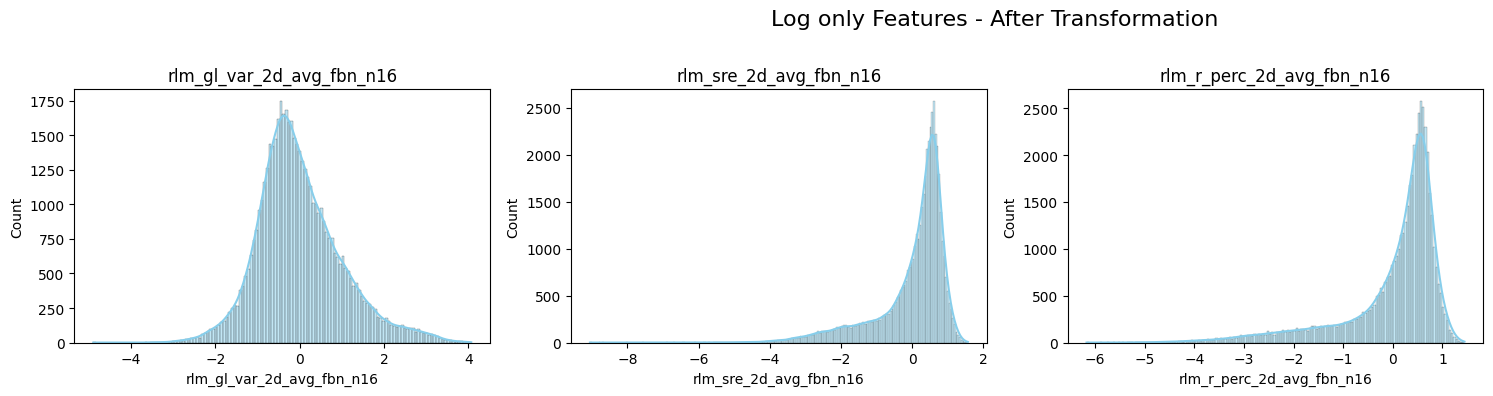

In [49]:
# Log only features
log_df = dataset.copy()
log_df[LOG_FEATURES] = np.log1p(log_df[LOG_FEATURES])
log_scaler = StandardScaler()
log_df[LOG_FEATURES] = log_scaler.fit_transform(log_df[LOG_FEATURES])
plot_features_separate(dataset, LOG_FEATURES, "Log only Features - Before Transformation")
plot_features_separate(log_df, LOG_FEATURES, "Log only Features - After Transformation")

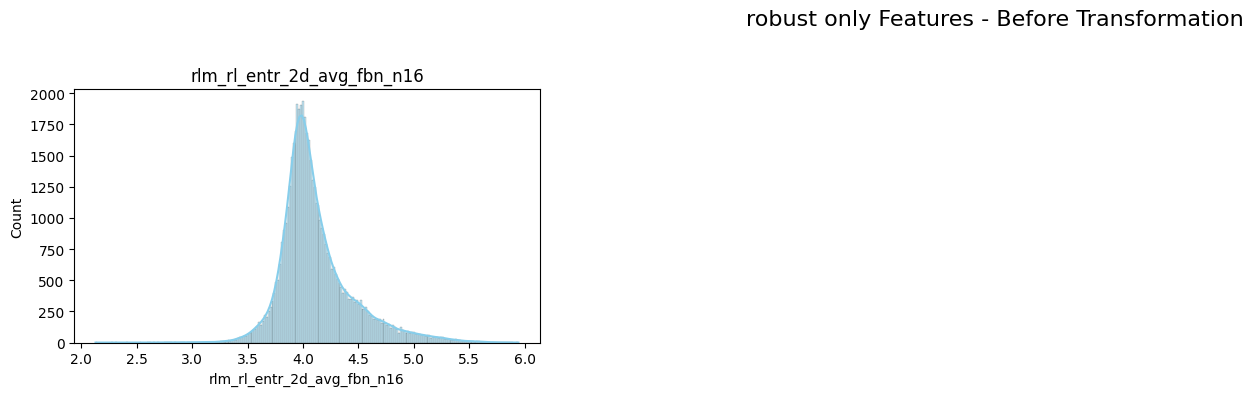

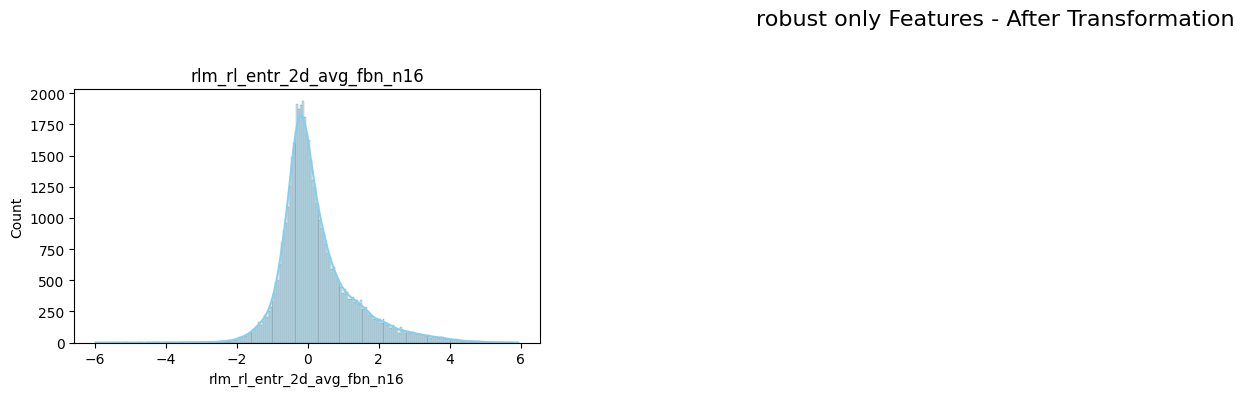

In [47]:
robust_df = dataset.copy()
robust_scaler = RobustScaler()
robust_df[SCALER_ONLY_FEATURES] = robust_scaler.fit_transform(robust_df[SCALER_ONLY_FEATURES])
plot_features_separate(dataset, SCALER_ONLY_FEATURES, "robust only Features - Before Transformation")
plot_features_separate(robust_df, SCALER_ONLY_FEATURES, "robust only Features - After Transformation")